# 02 · Logistic Regression baseline

**Objective.** Estimate the probability of default `P(Y = 1 | X)` on
`application_train` with the plainest defensible model, and measure how good those
probabilities are. This is the reference every later model must beat on the same
split and the same metrics.

**What this notebook deliberately does not do.** No decision threshold is chosen, no
class re-weighting is applied (it would move the probabilities away from the true
base rate), and no probability recalibration is performed. Calibration is
*measured* only.

**Reproducibility.** The whole experiment is `riskpilot.models.train.run_baseline`,
the same function behind `python -m riskpilot.models.train`. Running this notebook
re-fits the model and re-writes the artifacts in `artifacts/`; because the split
seed and the solver are deterministic, the numbers are identical to the CLI run.

In [1]:
import json
import logging

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from IPython.display import Image, Markdown, display

from riskpilot import config
from riskpilot.data.load import load_application_train, split_features_target
from riskpilot.features.preprocessing import clean_features
from riskpilot.models.evaluate import (
    GRID_COLOR,
    MODEL_COLOR,
    REFERENCE_COLOR,
    calibration_slope_intercept,
    calibration_table,
    expected_calibration_error,
)
from riskpilot.models.train import BaselineConfig, make_split, run_baseline

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": GRID_COLOR,
        "axes.grid": True,
        "grid.color": GRID_COLOR,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    }
)

## 1. Run the experiment

`BaselineConfig` holds every knob. Defaults: 80/20 stratified holdout with seed 42,
`LogisticRegression(solver="lbfgs", C=1.0, max_iter=1000)` with the L2 penalty and
no class weights, ten quantile bins for calibration.

In [2]:
cfg = BaselineConfig()
pd.Series(cfg.to_dict(), name="value")

data_path             data/raw/application_train.csv
nrows                                           None
test_size                                        0.2
random_state                                      42
C                                                1.0
max_iter                                        1000
class_weight                                    None
n_calibration_bins                                10
prefix                                      baseline
figures_dir                        artifacts/figures
metrics_dir                        artifacts/metrics
models_dir                          artifacts/models
processed_dir                         data/processed
save_model                                      True
save_split                                      True
sentinels                {'DAYS_EMPLOYED': 365243.0}
Name: value, dtype: object

In [3]:
result = run_baseline(cfg)
payload = result.payload

INFO riskpilot.data.load: Loaded application_train.csv: 307511 rows x 122 columns


INFO riskpilot.models.train: Split: train=246008 (prevalence 0.0807) | test=61503 (prevalence 0.0807)


INFO riskpilot.models.train: Fitted in 33.7s | lbfgs iterations=123 | transformed features=312 | converged=True


INFO riskpilot.models.train: Saved fitted pipeline to artifacts/models/baseline_logistic_regression.joblib


INFO riskpilot.models.train: Saved metrics to artifacts/metrics/baseline_metrics.json


In [4]:
display(pd.Series(payload["data"], name="data"))
display(pd.Series(payload["split"], name="split"))
display(pd.Series(payload["model"], name="model"))

path                      data/raw/application_train.csv
n_rows                                            307511
n_raw_features                                       120
n_numeric_features                                   104
n_categorical_features                                16
n_transformed_features                               312
Name: data, dtype: object

strategy                               stratified_random_holdout
test_size                                                    0.2
random_state                                                  42
n_train                                                   246008
n_test                                                     61503
prevalence_train                                        0.080729
prevalence_test                                         0.080728
membership_file     data/processed/baseline_split_membership.csv
Name: split, dtype: object

estimator         LogisticRegression
solver                         lbfgs
penalty                           l2
C                                1.0
class_weight                    None
max_iter                        1000
n_iter                           123
converged                       True
fit_seconds                     33.7
intercept                  -0.573608
n_coefficients                   312
Name: model, dtype: object

## 2. Convergence and warnings

`run_baseline` fits inside a `warnings.catch_warnings(record=True)` block that
*records* whether scikit-learn raised a `ConvergenceWarning`; nothing is silenced,
and the outcome is written to the metrics file. On the real data lbfgs converged
well within its budget (see `n_iter` versus `max_iter` above), which also answers a
question raised in notebook 01: the redundant missing-indicator columns and the
columns with huge single-row z-scores make the problem ill-conditioned, but not
enough to stop the optimizer.

## 3. Metrics against the null model

Ranking quality and probability quality are reported separately. The reference
column is the constant model that predicts the prevalence for everybody: it has
ROC-AUC 0.5, average precision equal to the prevalence, and the log loss / Brier
score of a perfectly calibrated but useless forecaster. For the calibration rows the
reference is the ideal value (ECE 0, slope 1, intercept 0).

In [5]:
rows = [
    "roc_auc", "average_precision", "log_loss", "brier_score", "brier_skill_score",
    "expected_calibration_error", "calibration_slope", "calibration_intercept",
    "mean_predicted_probability", "median_predicted_probability", "max_predicted_probability",
]
m_test, m_train = payload["metrics"]["test"], payload["metrics"]["train"]
reference = {
    "roc_auc": 0.5,
    "average_precision": m_test["average_precision_prevalence_baseline"],
    "log_loss": m_test["log_loss_prevalence_baseline"],
    "brier_score": m_test["brier_prevalence_baseline"],
    "brier_skill_score": 0.0,
    "expected_calibration_error": 0.0,
    "calibration_slope": 1.0,
    "calibration_intercept": 0.0,
    "mean_predicted_probability": m_test["prevalence"],
}
metrics = pd.DataFrame(
    {
        "test": {k: m_test[k] for k in rows},
        "train": {k: m_train[k] for k in rows},
        "reference": pd.Series(reference),
    }
)
metrics.round(4)

,test,train,reference
average_precision,0.2353,0.2292,0.0807
brier_score,0.0682,0.0684,0.0742
brier_skill_score,0.0808,0.0784,0.0000
calibration_intercept,0.0148,0.0022,0.0000
calibration_slope,1.0056,1.0011,1.0000
expected_calibration_error,0.0021,0.0010,0.0000
log_loss,0.2482,0.2484,0.2805
max_predicted_probability,0.7443,0.9532,NaN
mean_predicted_probability,0.0805,0.0807,0.0807
median_predicted_probability,0.0554,0.0556,NaN


**Reading.** ROC-AUC 0.750 and average precision 0.235 (2.9 × the prevalence) on the
untouched test partition. Log loss and Brier score both beat the null model; the
Brier skill score of 0.081 says the model removes about 8 % of the null model's
squared error, which is what a linear model on raw application features achieves on
this dataset. Train and test agree to the third decimal: with 246k rows, 312
coefficients and an L2 penalty there is no overfitting to speak of.

## 4. Figures

Generated by `riskpilot.models.evaluate.make_evaluation_figures` during the run and
saved under `artifacts/figures/`; displayed here from disk rather than re-plotted.

**roc curve** — `artifacts/figures/baseline_roc_curve.png`

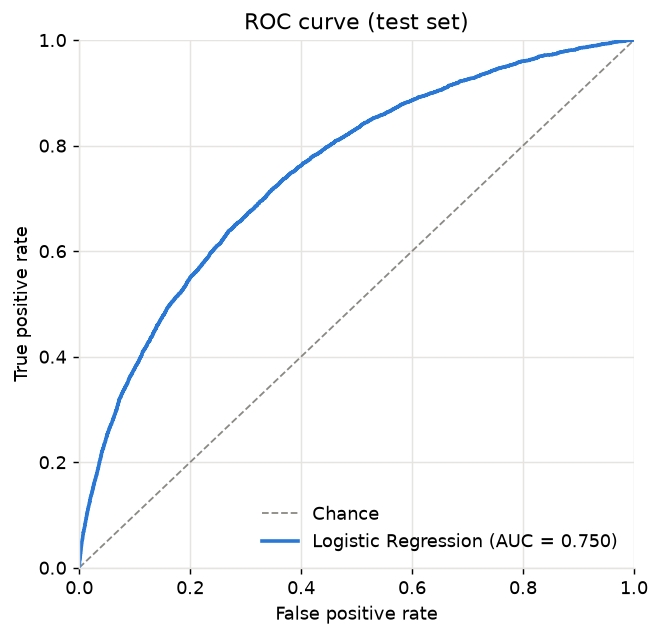

**precision recall curve** — `artifacts/figures/baseline_precision_recall_curve.png`

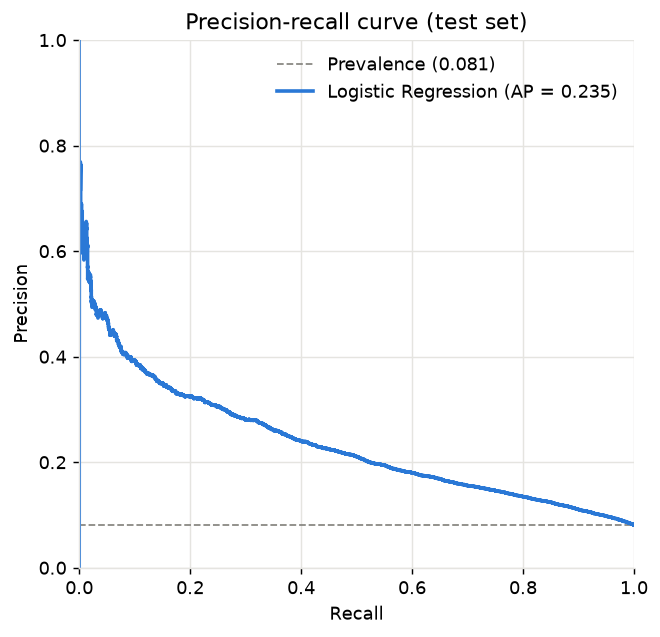

**calibration curve** — `artifacts/figures/baseline_calibration_curve.png`

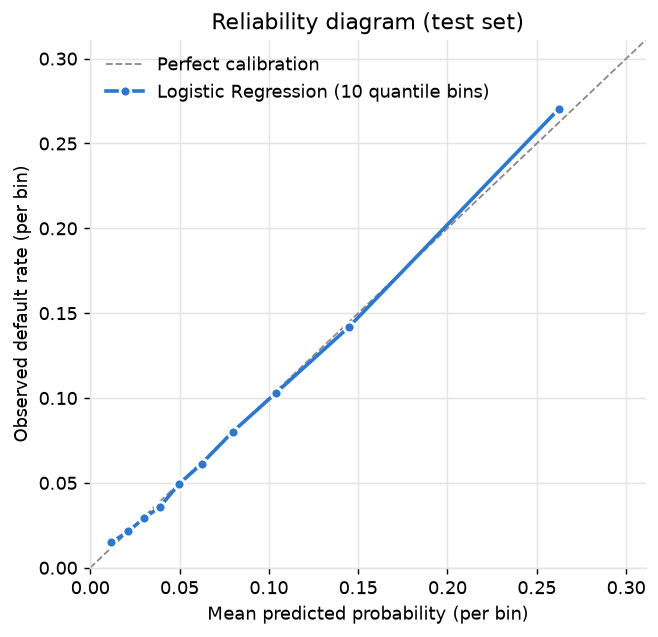

**probability distribution** — `artifacts/figures/baseline_probability_distribution.png`

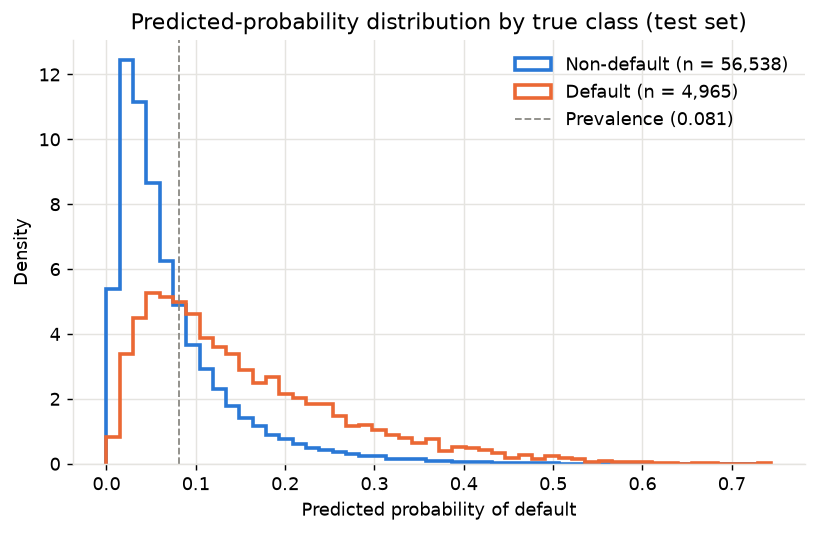

In [6]:
for name, path in payload["artifacts"]["figures"].items():
    display(Markdown(f"**{name.replace('_', ' ')}** — `{path}`"))
    display(Image(filename=str(config.PROJECT_ROOT / path), width=520))

## 5. Calibration

Three complementary views: the ten-quantile reliability table produced by the run,
a uniform-bin table (which exposes how sparse the high-probability tail is), and a
slope/intercept diagnostic — a logistic regression of the outcome on the predicted
log-odds, where slope 1 and intercept 0 mean calibrated. The diagnostic is *measured*
and reported; the probabilities are not adjusted.

,bin,lower,upper,n,mean_predicted,observed_rate,gap
0,0,0.0000,0.0171,6151,0.0119,0.0150,0.0031
1,1,0.0171,0.0256,6150,0.0214,0.0215,0.0001
2,2,0.0256,0.0343,6150,0.0299,0.0291,-0.0008
3,3,0.0343,0.0439,6150,0.0390,0.0358,-0.0032
4,4,0.0439,0.0554,6150,0.0495,0.0491,-0.0004
5,5,0.0554,0.0702,6151,0.0624,0.0613,-0.0011
6,6,0.0702,0.0902,6150,0.0797,0.0800,0.0003
7,7,0.0902,0.1206,6150,0.1042,0.1033,-0.0010
8,8,0.1206,0.1769,6150,0.1449,0.1420,-0.0030
9,9,0.1769,0.7443,6151,0.2623,0.2704,0.0081


,bin,lower,upper,n,mean_predicted,observed_rate,gap
0,0,0.0,0.1,45342,0.0446,0.0447,0.0001
1,1,0.1,0.2,11426,0.1384,0.1366,-0.0017
2,2,0.2,0.3,3218,0.2408,0.2508,0.0100
3,3,0.3,0.4,1073,0.3408,0.3346,-0.0062
4,4,0.4,0.5,336,0.4392,0.4256,-0.0136
5,5,0.5,0.6,94,0.5340,0.6064,0.0724
6,6,0.6,0.7,12,0.6263,0.7500,0.1237
7,7,0.7,0.8,2,0.7409,0.5000,-0.2409


calibration-in-the-large: mean predicted 0.0805 vs observed 0.0807
calibration slope 1.006 (ideal 1) | intercept 0.015 (ideal 0) -- diagnostic only
ECE: 10 quantile bins 0.0021 | 20 quantile bins 0.0045 | 10 uniform bins 0.0012
largest decile gap 0.0081: top decile predicted 0.262, observed 0.270 +/- 0.011 (95 %)
test rows with predicted probability > 0.5: 108 of 61,503 (0.18%)


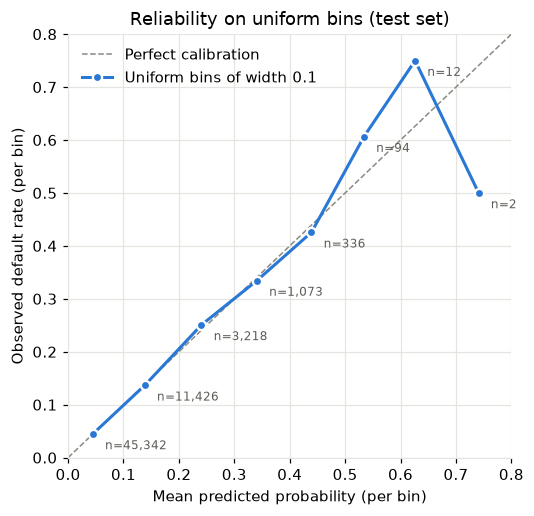

In [7]:
y_test, p_test = result.y_test.to_numpy(), result.y_prob_test
q10 = pd.DataFrame(payload["calibration_table_test"])
display(q10.round(4))
u10 = calibration_table(y_test, p_test, n_bins=10, strategy="uniform")
display(u10.round(4))
q20 = calibration_table(y_test, p_test, n_bins=20)

slope, intercept = calibration_slope_intercept(y_test, p_test)
top = q10.iloc[-1]
half_width = 1.96 * np.sqrt(top.observed_rate * (1 - top.observed_rate) / top.n)
print(f"calibration-in-the-large: mean predicted {p_test.mean():.4f} vs observed {y_test.mean():.4f}")
print(f"calibration slope {slope:.3f} (ideal 1) | intercept {intercept:.3f} (ideal 0) -- diagnostic only")
print(f"ECE: 10 quantile bins {expected_calibration_error(q10):.4f} | 20 quantile bins {expected_calibration_error(q20):.4f} | 10 uniform bins {expected_calibration_error(u10):.4f}")
print(f"largest decile gap {q10['gap'].abs().max():.4f}: top decile predicted {top.mean_predicted:.3f}, observed {top.observed_rate:.3f} +/- {half_width:.3f} (95 %)")
print(f"test rows with predicted probability > 0.5: {(p_test > 0.5).sum()} of {len(p_test):,} ({(p_test > 0.5).mean():.2%})")

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 0.8], [0, 0.8], color=REFERENCE_COLOR, linewidth=1, linestyle="--", label="Perfect calibration")
ax.plot(u10["mean_predicted"], u10["observed_rate"], color=MODEL_COLOR, linewidth=2, marker="o", markersize=6, markeredgecolor="white", markeredgewidth=1.5, label="Uniform bins of width 0.1")
for _, r in u10.iterrows():
    ax.annotate(f"n={int(r.n):,}", (r.mean_predicted, r.observed_rate), textcoords="offset points", xytext=(8, -10), fontsize=8, color="#5c5b57")
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed default rate (per bin)")
ax.set_title("Reliability on uniform bins (test set)")
ax.legend(loc="upper left")
plt.show()

**What the reliability analysis indicates.** The probabilities are calibrated in the
large (mean 0.0805 vs 0.0807 observed; this is a property of maximum-likelihood
logistic regression with an intercept and no re-weighting) and calibrated in shape:
slope 1.006, intercept 0.015, ECE 0.002 on ten quantile bins, every decile gap below
one percentage point. The only visible pattern is a slight under-prediction at both
extremes (bottom decile 1.2 % predicted vs 1.5 % observed; top decile 26.2 % vs
27.0 %), and the top-decile gap is inside its 95 % interval. Above a predicted
probability of 0.5 there are only about a hundred test applicants, so the
uniform-bin tail is not estimable and its wobble is noise, not miscalibration.

**Consequence.** There is no evidence that would justify Platt or isotonic
recalibration of this model; a recalibration milestone will have to demonstrate an
improvement on a proper held-out comparison rather than assume one. The
distribution, however, is narrow: the median applicant is scored at 5.5 % and 99 % of
applicants below 37 %, so the model separates risk groups modestly (the AUC of
0.75) even though the probabilities it does produce are trustworthy.

## 6. What the model learned

Coefficients are on standardized inputs (one unit = one training-split standard
deviation) for numeric columns and on 0/1 indicators for one-hot levels, so they are
comparable within a block, not across blocks, and always conditional on every other
feature.

intercept -0.574 | 312 coefficients | median |coef| 0.042 | 56 with |coef| < 0.01


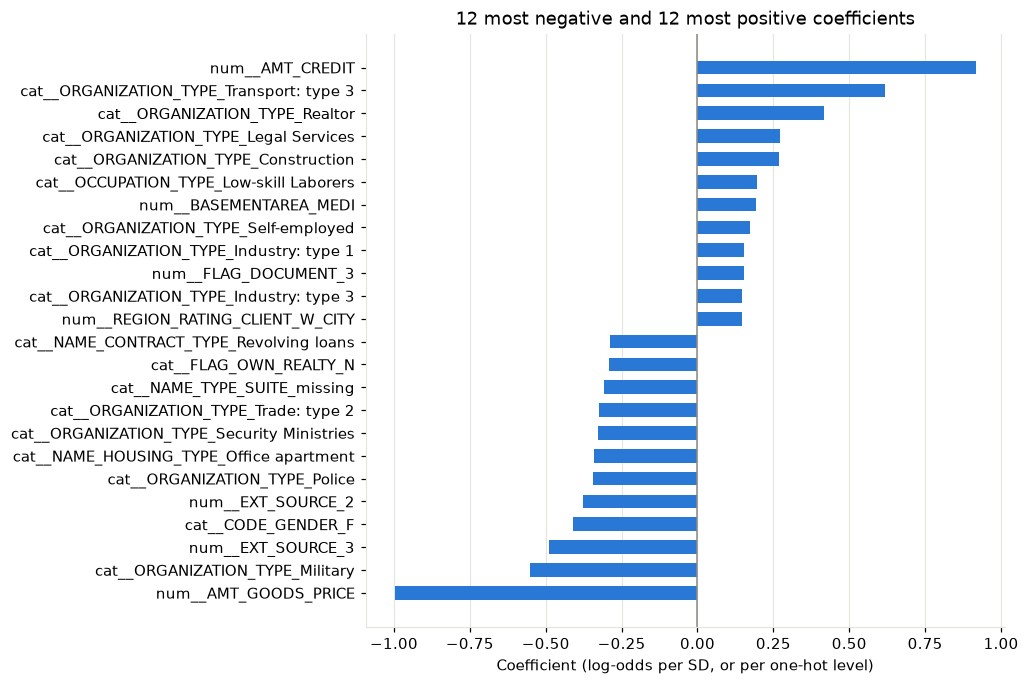

,coefficient
num__EXT_SOURCE_1,-0.1937
num__EXT_SOURCE_2,-0.3768
num__EXT_SOURCE_3,-0.4890
num__AMT_CREDIT,0.9169
num__AMT_GOODS_PRICE,-0.9980
num__AMT_INCOME_TOTAL,0.0068
num__DAYS_EMPLOYED,0.1410
num__missingindicator_DAYS_EMPLOYED,-0.0157
cat__NAME_INCOME_TYPE_Pensioner,-0.2554
cat__ORGANIZATION_TYPE_XNA,-0.1059


In [8]:
pipe = result.pipeline
names = pipe["preprocess"].get_feature_names_out()
coef = pd.Series(pipe["model"].coef_[0], index=names).sort_values()
print(f"intercept {pipe['model'].intercept_[0]:.3f} | {len(coef)} coefficients | median |coef| {coef.abs().median():.3f} | {(coef.abs() < 0.01).sum()} with |coef| < 0.01")

show = pd.concat([coef.head(12), coef.tail(12)])
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.barh(show.index, show.values, color=MODEL_COLOR, height=0.6)
ax.axvline(0, color=REFERENCE_COLOR, linewidth=1)
ax.set_xlabel("Coefficient (log-odds per SD, or per one-hot level)")
ax.set_title("12 most negative and 12 most positive coefficients")
ax.grid(axis="y", visible=False)
plt.show()

watch = [
    "num__EXT_SOURCE_1", "num__EXT_SOURCE_2", "num__EXT_SOURCE_3",
    "num__AMT_CREDIT", "num__AMT_GOODS_PRICE", "num__AMT_INCOME_TOTAL",
    "num__DAYS_EMPLOYED", "num__missingindicator_DAYS_EMPLOYED",
    "cat__NAME_INCOME_TYPE_Pensioner", "cat__ORGANIZATION_TYPE_XNA",
    "cat__CODE_GENDER_F", "cat__CODE_GENDER_XNA", "num__FLAG_MOBIL", "num__FLAG_DOCUMENT_12",
]
display(coef.reindex(watch).round(4).to_frame("coefficient"))

**Reading.** The three external scores carry the largest protective effects
(`EXT_SOURCE_3` −0.49, `EXT_SOURCE_2` −0.38, `EXT_SOURCE_1` −0.19 per SD), as the
univariate screen predicted. The largest coefficients in absolute value are the
near-collinear pair `AMT_CREDIT` (+0.92) and `AMT_GOODS_PRICE` (−1.00): the model
uses their *difference*, i.e. credit granted beyond the price of the goods raises
risk, a well-known signal in this dataset. Female applicants, military, police and
security-ministry employees are safer; some transport, realtor, legal-services and
construction employers, low-skill labourers and a poorer region rating are riskier.
The sentinel population is handled as intended: the `Pensioner` level and the
`ORGANIZATION_TYPE_XNA` level both carry negative coefficients (lower risk), and the
`DAYS_EMPLOYED` missing indicator is close to zero because those two levels already
explain it. `AMT_INCOME_TOTAL` and the near-constant flags have coefficients near
zero — section 7 explains why.

## 7. Scaling diagnostics

Notebook 01 predicted that the 117M income and the near-constant flags would
stretch `StandardScaler`. Here the fitted numeric transformer of the pipeline is
applied to the training split to measure the largest |z| per column, and the
split is re-derived from the same seed to confirm it matches the persisted membership
file. This cell reloads the raw table (≈ 0.5 GB).

In [9]:
df = load_application_train()
X, y = split_features_target(df)
ids = df[config.ID_COL]
del df
X_train, X_test, y_train, y_test_check = make_split(X, y, test_size=cfg.test_size, random_state=cfg.random_state)
del X
membership = pd.read_csv(config.PROJECT_ROOT / payload["split"]["membership_file"])
same_split = set(membership.loc[membership["split"] == "test", config.ID_COL]) == set(ids.loc[X_test.index])
print("persisted split membership matches the re-derived split:", same_split)
assert same_split and (y_test_check.to_numpy() == y_test).all()

num_pipe = pipe["preprocess"].named_transformers_["num"]
num_cols = list(pipe["preprocess"].transformers_[0][2])
Z = num_pipe.transform(clean_features(X_train[num_cols]))
z_names = [n.removeprefix("num__") for n in names[: Z.shape[1]]]
zmax = pd.Series(np.abs(Z).max(axis=0), index=z_names).sort_values(ascending=False)
del Z
print(f"standardized columns (numeric + indicators): {len(zmax)} | with a training row at |z| > 50: {(zmax > 50).sum()} | > 20: {(zmax > 20).sum()} | > 10: {(zmax > 10).sum()}")
display(zmax.head(15).round(1).to_frame("max |z| in the training split"))

scaler = num_pipe["scale"]
j = num_cols.index("AMT_INCOME_TOTAL")
print(f"AMT_INCOME_TOTAL: one standard deviation = {scaler.scale_[j]:,.0f} (would be ~{X_train.loc[X_train['AMT_INCOME_TOTAL'] < 1e8, 'AMT_INCOME_TOTAL'].std():,.0f} without the 117M row); coefficient {coef['num__AMT_INCOME_TOTAL']:+.4f} per SD")
print(f"FLAG_MOBIL: coefficient {coef['num__FLAG_MOBIL']:+.4f}; the single deviating row is shifted by {coef['num__FLAG_MOBIL'] * zmax['FLAG_MOBIL']:+.2f} log-odds, every other row by {coef['num__FLAG_MOBIL'] / zmax['FLAG_MOBIL']:+.5f}")

Xt_test = pipe[:-1].transform(X_test)
size_mb = (Xt_test.data.nbytes if sp.issparse(Xt_test) else Xt_test.nbytes) / 1e6
print(f"design matrix of the test split: shape {Xt_test.shape}, sparse={sp.issparse(Xt_test)}, {size_mb:.0f} MB -> {size_mb * len(X_train) / len(X_test):.0f} MB for the training split")
del Xt_test

INFO riskpilot.data.load: Loaded application_train.csv: 307511 rows x 122 columns


persisted split membership matches the re-derived split: True


standardized columns (numeric + indicators): 166 | with a training row at |z| > 50: 18 | > 20: 40 | > 10: 75


,max |z| in the training split
FLAG_MOBIL,496.0
missingindicator_DAYS_LAST_PHONE_CHANGE,496.0
FLAG_DOCUMENT_12,496.0
AMT_INCOME_TOTAL,451.2
missingindicator_CNT_FAM_MEMBERS,350.7
FLAG_DOCUMENT_10,248.0
missingindicator_AMT_ANNUITY,156.8
FLAG_DOCUMENT_2,149.5
OBS_30_CNT_SOCIAL_CIRCLE,143.4
OBS_60_CNT_SOCIAL_CIRCLE,143.0


AMT_INCOME_TOTAL: one standard deviation = 258,960 (would be ~107,593 without the 117M row); coefficient +0.0068 per SD
FLAG_MOBIL: coefficient +0.0087; the single deviating row is shifted by +4.30 log-odds, every other row by +0.00002


design matrix of the test split: shape (61503, 312), sparse=False, 154 MB -> 614 MB for the training split


**Reading.** Eighteen standardized columns contain a training row at |z| > 50, three
of them at |z| ≈ 500 (`FLAG_MOBIL`, `FLAG_DOCUMENT_12` and the `DAYS_LAST_PHONE_CHANGE`
indicator are each violated by a single row), and the 117M income sits at z ≈ 450.
The fitted model responds by giving those columns coefficients of a few thousandths:
the extreme row gets a private log-odds shift while everyone else is unaffected. So
the scaling does what it is supposed to for the bulk of the data and does not distort
other applicants' scores; its cost is that a heavy-tailed but legitimate feature such
as income is effectively discarded (one SD of income is 259k because of one row). The
one-hot block leaves the encoder sparse, but the `ColumnTransformer` densifies the
output because the 166 numeric and indicator columns dominate; at ≈ 0.6 GB for the
training split this is acceptable on a laptop and is why the fit takes ~30 s.
These are recorded as candidate preprocessing revisions (robust or log scaling for
amounts, unscaled 0/1 flags) to be *compared* against this baseline in the next
milestone, not applied silently now.

## 8. Reproducibility checks

The persisted pipeline must reproduce the in-memory probabilities, and the metrics
file must agree with the in-memory payload.

In [10]:
reloaded = joblib.load(config.PROJECT_ROOT / payload["artifacts"]["model"])
p_again = reloaded.predict_proba(X_test)[:, 1]
print("persisted pipeline reproduces the test probabilities:", bool(np.allclose(p_again, p_test)))

saved = json.loads(result.metrics_path.read_text(encoding="utf-8"))
print("metrics file agrees with the in-memory payload:", saved["metrics"] == payload["metrics"])
print("metrics file:", result.metrics_path.relative_to(config.PROJECT_ROOT).as_posix())

persisted pipeline reproduces the test probabilities: True
metrics file agrees with the in-memory payload: True
metrics file: artifacts/metrics/baseline_metrics.json


## 9. Conclusions

* **Honest baseline established.** ROC-AUC 0.750, average precision 0.235, log loss
  0.248 (null 0.281), Brier 0.0682 (null 0.0742), Brier skill score 0.081, ECE 0.002
  on the untouched 20 % partition, with lbfgs converged and no warning suppressed.
* **Probabilities are trustworthy but timid.** Calibration slope 1.006, intercept
  0.015; the model rarely predicts above 0.4. Improving discrimination, not
  calibration, is the lever for the next models.
* **The preprocessing assumptions held**, with two quantified caveats (the income
  outlier and the near-constant flags under standardization) that cost signal but
  do not distort other scores.
* **Deferred on purpose:** decision thresholds and cost-sensitive policies, class
  weights, recalibration, robust scaling / log transforms, feature engineering over
  the relational tables, and challenger models — all to be evaluated on the split
  persisted in `data/processed/baseline_split_membership.csv`.